In [22]:
# Cell 1: Khai báo thư viện
print('Đang khai báo thư viện')

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

print('Khai báo thư viện thành công')

Đang khai báo thư viện
Khai báo thư viện thành công


In [23]:
# Cell 2: Khai báo dữ liệu
print('Khai báo dữ liệu')

train_path = os.path.join("..", "Data", "DataCleaned", "data_train_cleaned.csv")
val_path = os.path.join("..", "Data", "DataCleaned", "validation_cleaned.csv")

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)

print("THÔNG TIN DỮ LIỆU")
print(f"Train shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"\nTrain columns:\n{df_train.columns.tolist()}")
print(f"\nClass distribution trong train:\n{df_train['Class'].value_counts().sort_index()}")
print(f"\nClass distribution trong validation:\n{df_val['Class'].value_counts().sort_index()}")

Khai báo dữ liệu
THÔNG TIN DỮ LIỆU
Train shape: (11516, 20)
Validation shape: (2880, 17)

Train columns:
['Id', 'Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'Class', 'key_sin', 'key_cos']

Class distribution trong train:
Class
0      400
1      878
2      814
3      258
4      248
5      926
6     1655
7      369
8     1186
9     1615
10    3167
Name: count, dtype: int64

Class distribution trong validation:
Class
0     100
1     220
2     204
3      64
4      62
5     231
6     414
7      92
8     297
9     404
10    792
Name: count, dtype: int64


In [24]:
# Cell 3: So sánh phân bố class
train_dist = df_train['Class'].value_counts(normalize=True).sort_index().rename('train_%')
val_dist = df_val['Class'].value_counts(normalize=True).sort_index().rename('val_%')
print(pd.concat([train_dist, val_dist], axis=1).round(4))

       train_%   val_%
Class                 
0       0.0347  0.0347
1       0.0762  0.0764
2       0.0707  0.0708
3       0.0224  0.0222
4       0.0215  0.0215
5       0.0804  0.0802
6       0.1437  0.1438
7       0.0320  0.0319
8       0.1030  0.1031
9       0.1402  0.1403
10      0.2750  0.2750


In [25]:
# Cell 4: So sánh mean của từng feature
drop_cols = ['Id', 'Artist Name', 'Track Name', 'Key']
existing_drop_train = [col for col in drop_cols if col in df_train.columns]
existing_drop_val = [col for col in drop_cols if col in df_val.columns]

X_train = df_train.drop(columns=['Class'] + existing_drop_train)
y_train = df_train['Class']

X_val = df_val.drop(columns=['Class'] + existing_drop_val)
y_val = df_val['Class']

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

# So sánh mean
compare = pd.DataFrame({
    'train_mean': X_train.mean(),
    'val_mean': X_val.mean(),
    'diff_pct': ((X_train.mean() - X_val.mean()) / X_train.mean() * 100).round(2)
})
print(compare.sort_values('diff_pct', key=abs, ascending=False))

X_train shape: (11516, 16)
X_val shape: (2880, 16)
                     train_mean       val_mean  diff_pct
key_sin                0.010156       0.025233   -148.45
instrumentalness       0.135972       0.132591      2.49
mode                   0.637635       0.650694     -2.05
valence                0.484816       0.492630     -1.61
key_cos               -0.186101      -0.188528     -1.30
Popularity            44.629298      44.048264      1.30
key                    6.083015       6.021528      1.01
duration_ms       234063.474870  232018.650311      0.87
danceability           0.543655       0.540908      0.51
liveness               0.195609       0.196473     -0.44
time_signature         3.927058       3.913542      0.34
loudness              -7.864334      -7.886753     -0.29
speechiness            0.080222       0.080017      0.26
tempo                122.739634     122.510843      0.19
energy                 0.662289       0.662952     -0.10
acousticness           0.246707      

In [26]:
# Cell 5: Train XGBoost model
print("\n" + "="*55)
print("TRAINING XGBOOST MODEL")
print("="*55)

# Tính sample weights để xử lý mất cân bằng class
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"✅ Train xong!")
print(f"   n_estimators : {xgb.n_estimators}")
print(f"   max_depth    : {xgb.max_depth}")
print(f"   learning_rate: {xgb.learning_rate}")


TRAINING XGBOOST MODEL
✅ Train xong!
   n_estimators : 300
   max_depth    : 12
   learning_rate: 0.05


In [27]:
# Cell 6: Train XGBoost với Early Stopping (Không dùng GridSearch)
print("\n" + "="*55)
print("🔍 TRAINING XGBOOST WITH EARLY STOPPING")
print("="*55)
print("⏱️ Quá trình này có thể mất vài phút...")

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    min_child_weight=3,
    early_stopping_rounds=50,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\n✅ Best iteration: {xgb.best_iteration}")
print(f"✅ Best validation score: {xgb.best_score}")

# Gán best_xgb để tương thích với các cell sau
best_xgb = xgb


🔍 TRAINING XGBOOST WITH EARLY STOPPING
⏱️ Quá trình này có thể mất vài phút...
[0]	validation_0-mlogloss:2.35201
[50]	validation_0-mlogloss:1.63690
[100]	validation_0-mlogloss:1.52011
[150]	validation_0-mlogloss:1.48832
[200]	validation_0-mlogloss:1.47941
[250]	validation_0-mlogloss:1.48125
[272]	validation_0-mlogloss:1.48573

✅ Best iteration: 222
✅ Best validation score: 1.4783112373129472


In [15]:
# Cell 7: Dự đoán và đánh giá (GIỮ NGUYÊN - dùng xgb)
print("\n" + "="*55)
print("XGBOOST - PREDICT & EVALUATE")
print("="*55)

y_pred_train = xgb.predict(X_train)
y_pred_val = xgb.predict(X_val)

acc_train = accuracy_score(y_train, y_pred_train)
acc_val = accuracy_score(y_val, y_pred_val)

print("ACCURACY")
print("="*55)
print(f"  Train      : {acc_train:.4f} ({acc_train*100:.2f}%)")
print(f"  Validation : {acc_val:.4f} ({acc_val*100:.2f}%)")
print(f"  Gap        : {acc_train - acc_val:.4f}  ", end="")
if acc_train - acc_val > 0.1:
    print("⚠️ Có dấu hiệu Overfitting")
elif acc_val < 0.5:
    print("⚠️ Model yếu — Underfitting")
else:
    print("✅ Ổn định")


XGBOOST - PREDICT & EVALUATE
ACCURACY
  Train      : 0.8352 (83.52%)
  Validation : 0.4340 (43.40%)
  Gap        : 0.4012  ⚠️ Có dấu hiệu Overfitting


In [28]:
# Cell 8: Classification Report chi tiết
print("="*55)
print("CLASSIFICATION REPORT — TRAIN")
print("="*55)
print(classification_report(y_train, y_pred_train, zero_division=0))

print("="*55)
print("CLASSIFICATION REPORT — VALIDATION")
print("="*55)
print(classification_report(y_val, y_pred_val, zero_division=0))

CLASSIFICATION REPORT — TRAIN
              precision    recall  f1-score   support

           0       0.73      1.00      0.85       400
           1       0.66      0.94      0.77       878
           2       0.81      0.99      0.89       814
           3       0.93      1.00      0.96       258
           4       0.73      1.00      0.84       248
           5       0.92      0.99      0.95       926
           6       0.87      0.72      0.79      1655
           7       0.97      1.00      0.98       369
           8       0.79      0.98      0.88      1186
           9       0.82      0.87      0.84      1615
          10       0.93      0.65      0.76      3167

    accuracy                           0.84     11516
   macro avg       0.83      0.92      0.87     11516
weighted avg       0.85      0.84      0.83     11516

CLASSIFICATION REPORT — VALIDATION
              precision    recall  f1-score   support

           0       0.25      0.41      0.31       100
           1 

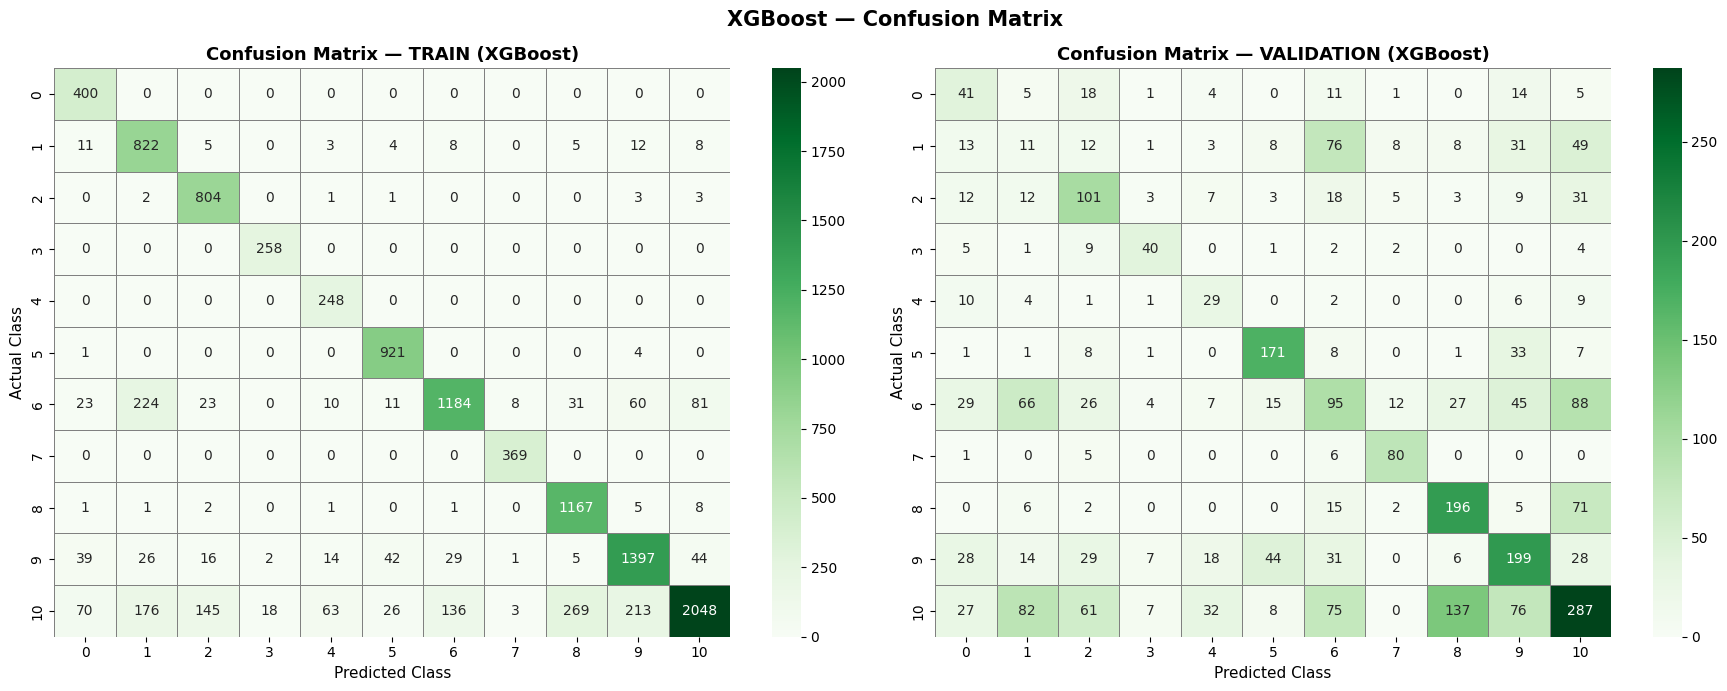

In [29]:
# Cell 9: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_val],
    [y_pred_train, y_pred_val],
    ['Confusion Matrix — TRAIN (XGBoost)', 'Confusion Matrix — VALIDATION (XGBoost)']
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=sorted(y_train.unique()),
                yticklabels=sorted(y_train.unique()),
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted Class', fontsize=11)
    ax.set_ylabel('Actual Class', fontsize=11)

plt.suptitle('XGBoost — Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

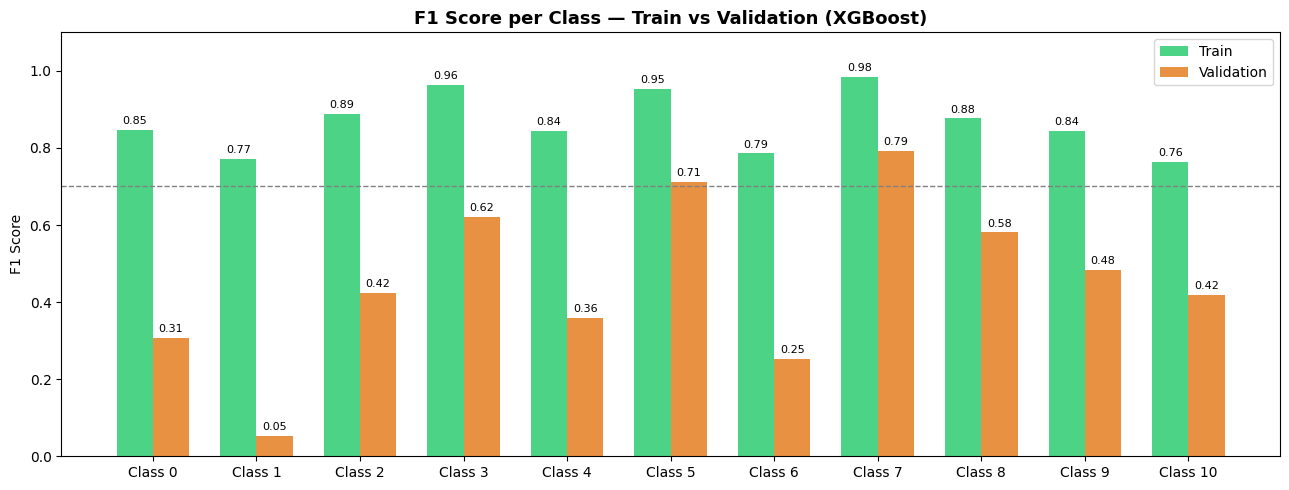

Class yếu nhất trên Validation (F1 < 0.7):
  Class  0: F1 = 0.3071
  Class  1: F1 = 0.0521
  Class  2: F1 = 0.4244
  Class  3: F1 = 0.6202
  Class  4: F1 = 0.3580
  Class  6: F1 = 0.2523
  Class  8: F1 = 0.5807
  Class  9: F1 = 0.4842
  Class 10: F1 = 0.4187


In [30]:
# Cell 10: Per-class F1 Score
classes = sorted(y_train.unique())
f1_train = f1_score(y_train, y_pred_train, average=None, labels=classes, zero_division=0)
f1_val = f1_score(y_val, y_pred_val, average=None, labels=classes, zero_division=0)

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, f1_train, width, label='Train', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_val, width, label='Validation', color='#e67e22', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Class {c}' for c in classes])
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1 Score per Class — Train vs Validation (XGBoost)', fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, label='threshold 0.7')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("Class yếu nhất trên Validation (F1 < 0.7):")
for c, f1 in zip(classes, f1_val):
    if f1 < 0.7:
        print(f"  Class {c:>2d}: F1 = {f1:.4f}")

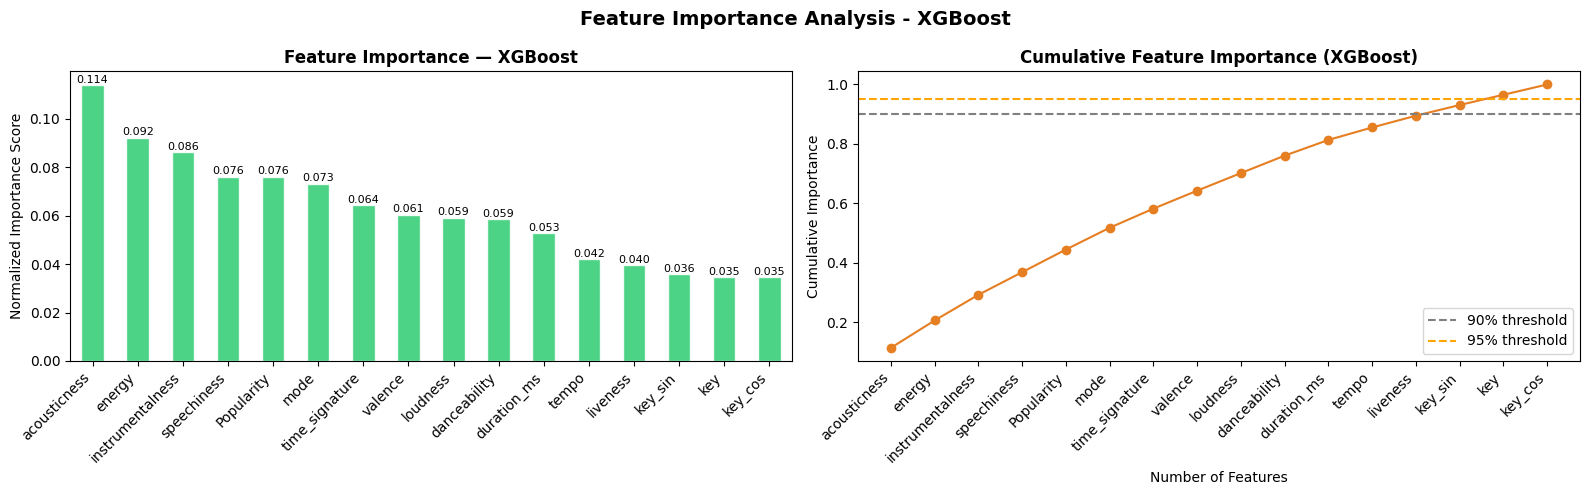


Top 5 features quan trọng nhất (XGBoost):
  acousticness             : 0.1140
  energy                   : 0.0922
  instrumentalness         : 0.0863
  speechiness              : 0.0762
  Popularity               : 0.0761

→ Chỉ cần 14 features để giải thích 90% importance


In [31]:
# Cell 11: Feature Importance
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)
feat_imp_norm = feat_imp / feat_imp.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
feat_imp_norm.plot(kind='bar', ax=axes[0], color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].set_title('Feature Importance — XGBoost', fontweight='bold')
axes[0].set_ylabel('Normalized Importance Score')
axes[0].set_xticklabels(feat_imp_norm.index, rotation=45, ha='right')
for i, v in enumerate(feat_imp_norm.values):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)

# Cumulative importance
cumsum = feat_imp_norm.cumsum()
axes[1].plot(range(1, len(cumsum)+1), cumsum.values, marker='o', color='#e67e22')
axes[1].axhline(0.9, color='gray', linestyle='--', label='90% threshold')
axes[1].axhline(0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Feature Importance (XGBoost)', fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_xticks(range(1, len(cumsum)+1))
axes[1].set_xticklabels(feat_imp_norm.index, rotation=45, ha='right')
axes[1].legend()

plt.suptitle('Feature Importance Analysis - XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 features quan trọng nhất (XGBoost):")
for feat, score in feat_imp_norm.head(5).items():
    print(f"  {feat:25s}: {score:.4f}")

n90 = (cumsum < 0.9).sum() + 1
print(f"\n→ Chỉ cần {n90} features để giải thích 90% importance")

In [32]:
# Cell 12: Tổng kết đánh giá XGBoost
macro_f1_train = f1_score(y_train, y_pred_train, average='macro', zero_division=0)
macro_f1_val = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
weighted_f1_val = f1_score(y_val, y_pred_val, average='weighted', zero_division=0)

print("╔══════════════════════════════════════════════╗")
print("║          TỔNG KẾT — XGBOOST MODEL            ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Accuracy   Train      : {acc_train:.4f}               ║")
print(f"║  Accuracy   Validation : {acc_val:.4f}               ║")
print(f"║  Macro F1   Train      : {macro_f1_train:.4f}               ║")
print(f"║  Macro F1   Validation : {macro_f1_val:.4f}               ║")
print(f"║  Weighted F1 Validation: {weighted_f1_val:.4f}               ║")
print(f"║  Overfitting gap       : {acc_train - acc_val:.4f}               ║")
print("╠══════════════════════════════════════════════╣")

gap = acc_train - acc_val
if gap > 0.1:
    print("║  ⚠️  OVERFITTING — cần giảm độ phức tạp     ║")
    print("║     → Thử: max_depth=8~10, tăng reg_alpha   ║")
elif acc_val < 0.5:
    print("║  ⚠️  UNDERFITTING — model chưa học được      ║")
    print("║     → Thử: tăng n_estimators, giảm learning_rate ║")
else:
    print("║  ✅  Model ổn định                           ║")

print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║          TỔNG KẾT — XGBOOST MODEL            ║
╠══════════════════════════════════════════════╣
║  Accuracy   Train      : 0.8352               ║
║  Accuracy   Validation : 0.4340               ║
║  Macro F1   Train      : 0.8657               ║
║  Macro F1   Validation : 0.4546               ║
║  Weighted F1 Validation: 0.4277               ║
║  Overfitting gap       : 0.4012               ║
╠══════════════════════════════════════════════╣
║  ⚠️  OVERFITTING — cần giảm độ phức tạp     ║
║     → Thử: max_depth=8~10, tăng reg_alpha   ║
╚══════════════════════════════════════════════╝


In [33]:
# Cell 13: Lưu model XGBoost
import joblib

# Tạo folder Model nếu chưa có
model_dir = os.path.join("..", "Model")
os.makedirs(model_dir, exist_ok=True)

# Lưu model
joblib.dump(xgb, os.path.join(model_dir, 'xgboost_model.pkl'))
print(f"✅ Đã lưu XGBoost model vào: {os.path.join(model_dir, 'xgboost_model.pkl')}")

# Lưu danh sách features
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, os.path.join(model_dir, 'feature_names_xgb.pkl'))
print(f"✅ Đã lưu danh sách features vào: {os.path.join(model_dir, 'feature_names_xgb.pkl')}")

print("\n🎉 XGBoost training completed successfully!")

✅ Đã lưu XGBoost model vào: ..\Model\xgboost_model.pkl
✅ Đã lưu danh sách features vào: ..\Model\feature_names_xgb.pkl

🎉 XGBoost training completed successfully!


In [34]:
# ════════════════════════════════════════════════════════
# CELL 14: TRAIN FINAL MODEL (train + val gộp lại)
# ════════════════════════════════════════════════════════

# Gộp train + validation
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print(f"Full dataset shape: {X_full.shape}")
print(f"Class distribution:\n{y_full.value_counts().sort_index()}")

# Tính sample weight trên full data
sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_full)

# Train final model với best params từ early stopping trước
# Dùng best_iteration từ model cũ làm n_estimators cố định (không early stopping)
best_iter = xgb.best_iteration
print(f"\nDùng n_estimators = {best_iter} (từ early stopping trước)")

xgb_final = XGBClassifier(
    n_estimators     = best_iter,
    max_depth        = 8,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    min_child_weight = 3,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

xgb_final.fit(X_full, y_full, sample_weight=sample_weights_full)
print("✅ Train final model xong!")

# Kiểm tra lại trên val (chỉ để tham khảo — val đã nằm trong train rồi nên không còn ý nghĩa đánh giá)
y_pred_full_check = xgb_final.predict(X_val)
print(f"\n[Tham khảo] Accuracy trên val: {accuracy_score(y_val, y_pred_full_check):.4f}")
print("(Số này sẽ cao hơn thực tế vì val đã được train)")

Full dataset shape: (14396, 16)
Class distribution:
Class
0      500
1     1098
2     1018
3      322
4      310
5     1157
6     2069
7      461
8     1483
9     2019
10    3959
Name: count, dtype: int64

Dùng n_estimators = 222 (từ early stopping trước)
✅ Train final model xong!

[Tham khảo] Accuracy trên val: 0.7892
(Số này sẽ cao hơn thực tế vì val đã được train)


In [35]:
# ════════════════════════════════════════════════════════
# CELL 15: LƯU FINAL MODEL
# ════════════════════════════════════════════════════════

joblib.dump(xgb_final, os.path.join("..", "Model", "xgboost_final_model.pkl"))
joblib.dump(X_full.columns.tolist(), os.path.join("..", "Model", "feature_names_xgb_final.pkl"))

print("✅ Đã lưu xgboost_final_model.pkl")
print("✅ Đã lưu feature_names_xgb_final.pkl")

✅ Đã lưu xgboost_final_model.pkl
✅ Đã lưu feature_names_xgb_final.pkl
